This question involves the use of multiple linear regression on the
Auto data set.


(a) Produce a scatterplot matrix which includes all of the variables
in the data set.


<Figure size 1100x1100 with 0 Axes>

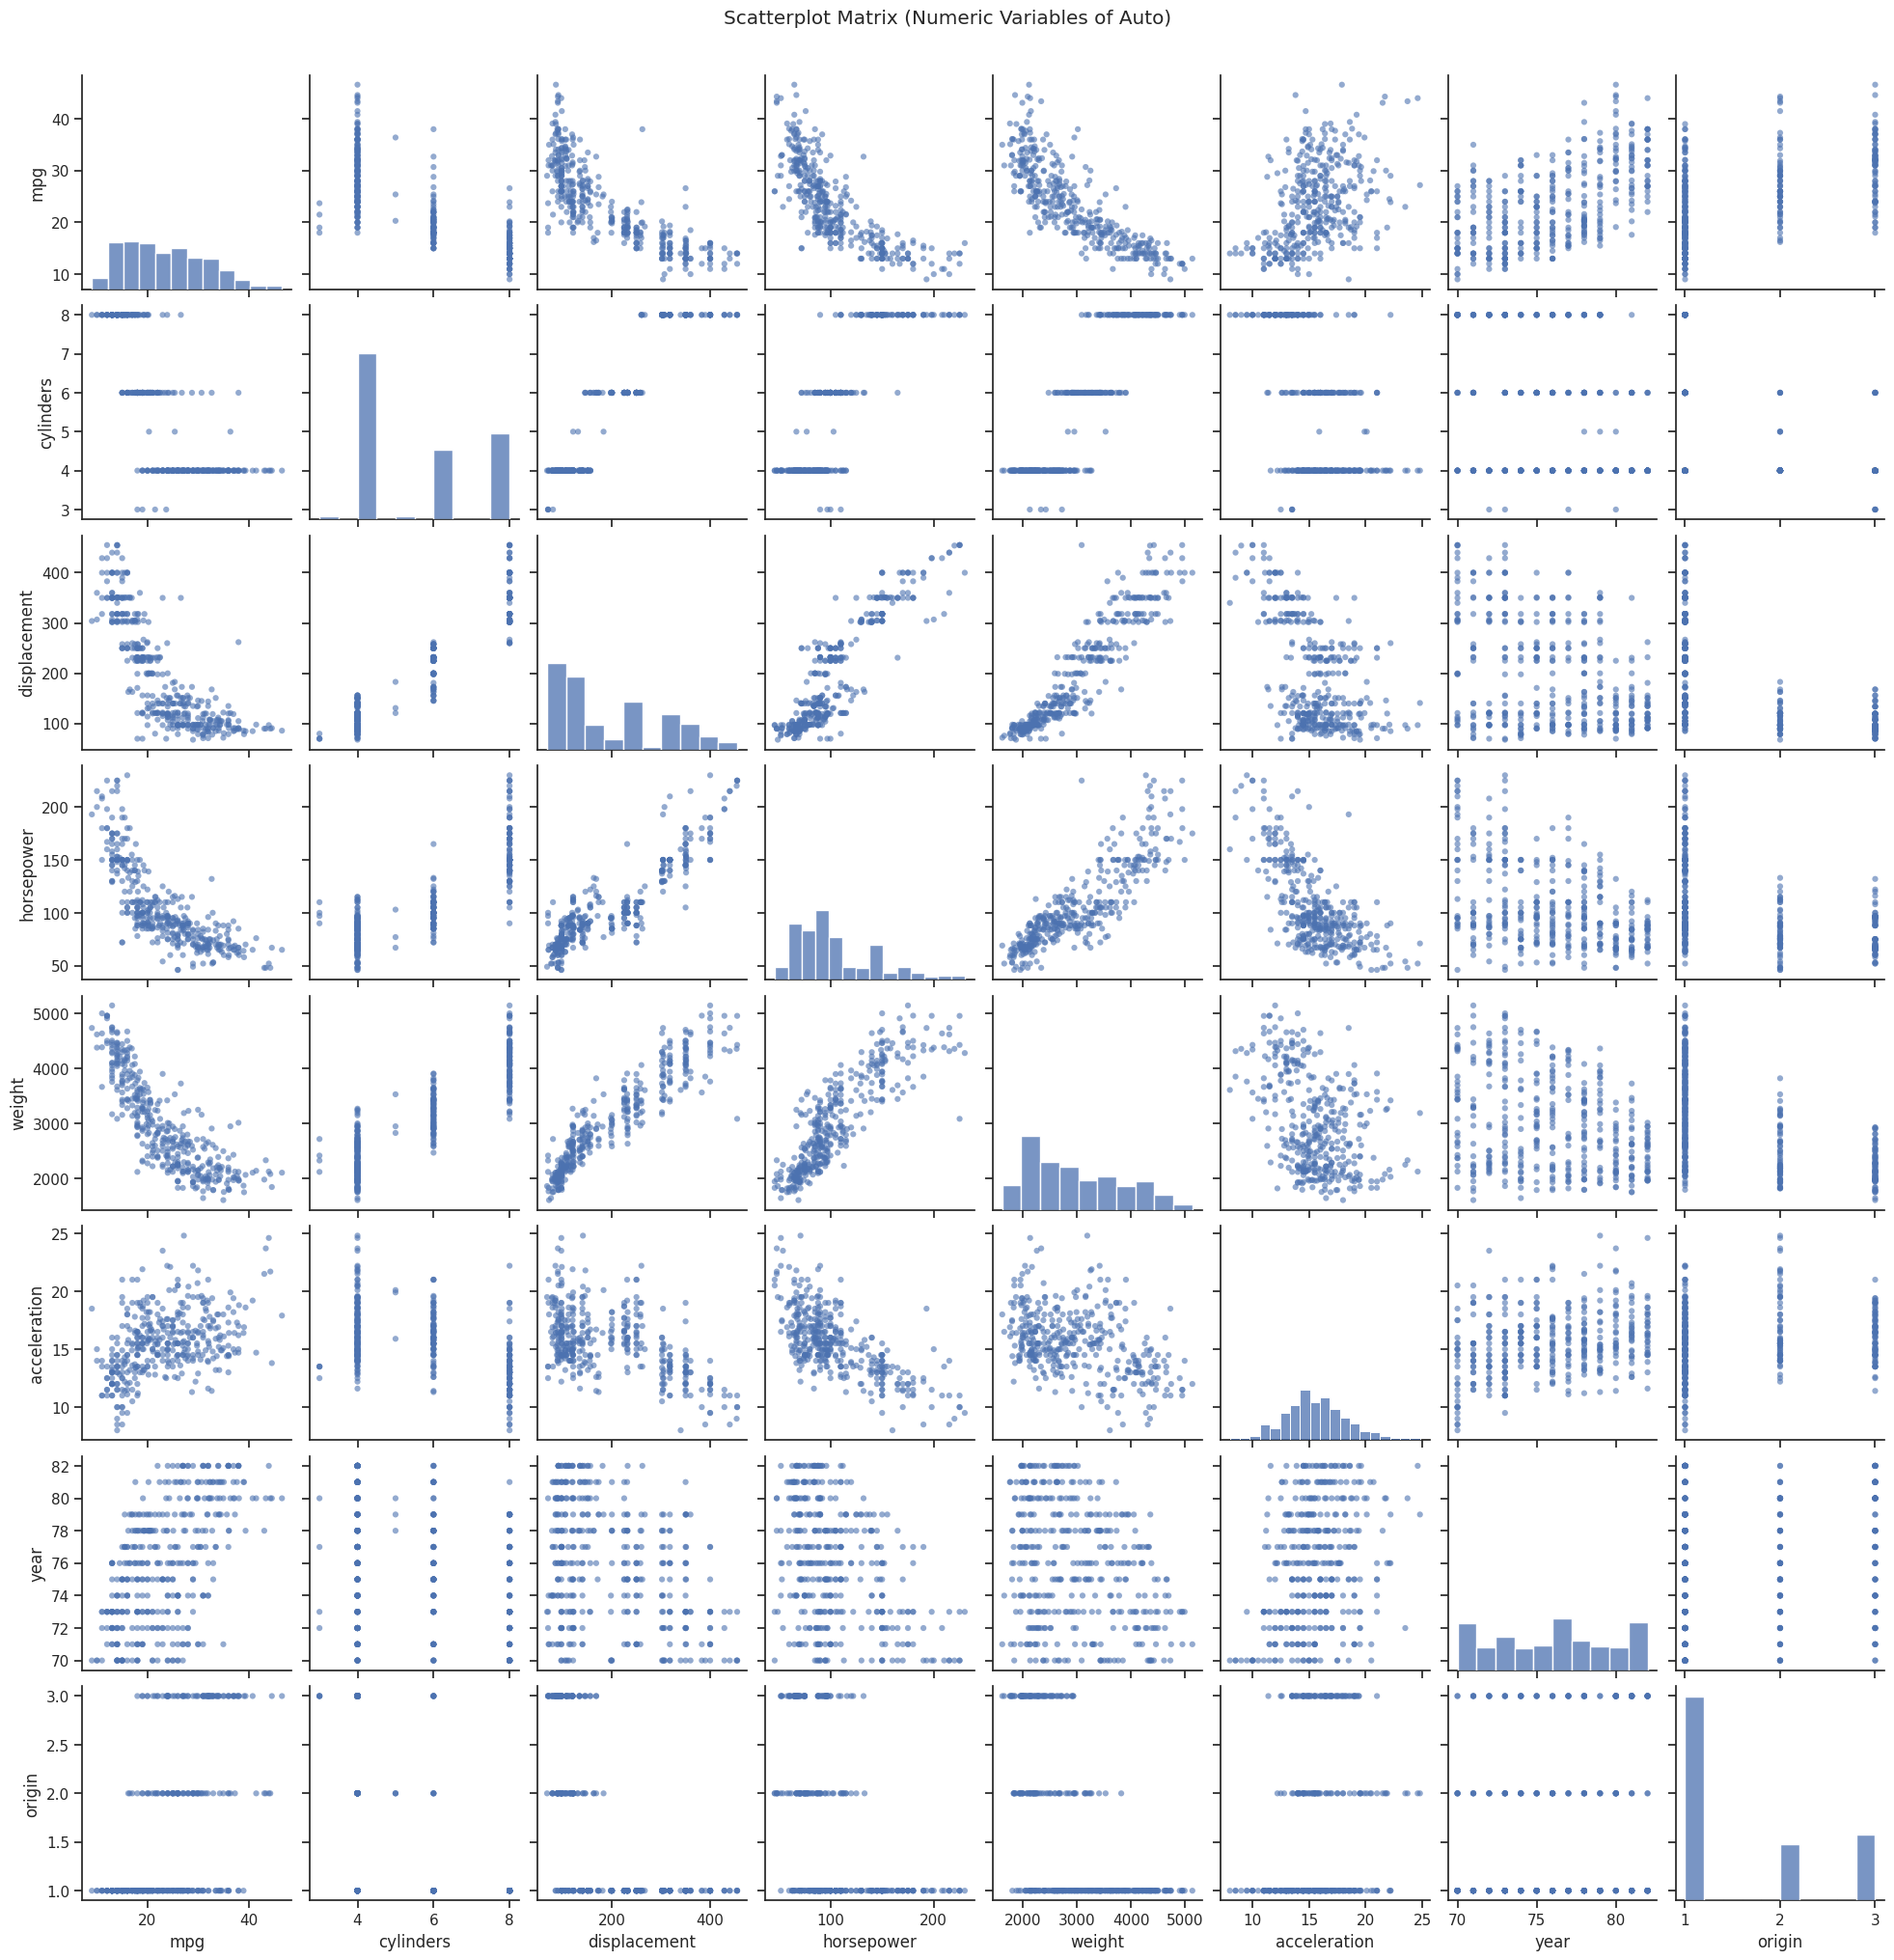

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.regressionplots import influence_plot

url = "https://www.statlearning.com/s/Auto.csv"
df = pd.read_csv(url)

df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df.dropna().copy()

numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
                'acceleration', 'year', 'origin']

# name 欄位為字串，排除
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

sns.set(style="ticks", context="notebook")
plt.figure(figsize=(11, 11))
sns.pairplot(df[numeric_cols], plot_kws=dict(alpha=0.6, s=20, edgecolor="none"))
plt.suptitle("Scatterplot Matrix (Numeric Variables of Auto)", y=1.02)
plt.show()

(b) Compute the matrix of correlations between the variables using
the DataFrame.corr() method.


Correlation matrix (numeric variables)
                    mpg  cylinders  displacement  horsepower    weight  \
mpg           1.000000  -0.777618     -0.805127   -0.778427 -0.832244   
cylinders    -0.777618   1.000000      0.950823    0.842983  0.897527   
displacement -0.805127   0.950823      1.000000    0.897257  0.932994   
horsepower   -0.778427   0.842983      0.897257    1.000000  0.864538   
weight       -0.832244   0.897527      0.932994    0.864538  1.000000   
acceleration  0.423329  -0.504683     -0.543800   -0.689196 -0.416839   
year          0.580541  -0.345647     -0.369855   -0.416361 -0.309120   
origin        0.565209  -0.568932     -0.614535   -0.455171 -0.585005   

              acceleration      year    origin  
mpg               0.423329  0.580541  0.565209  
cylinders        -0.504683 -0.345647 -0.568932  
displacement     -0.543800 -0.369855 -0.614535  
horsepower       -0.689196 -0.416361 -0.455171  
weight           -0.416839 -0.309120 -0.585005  
acceler

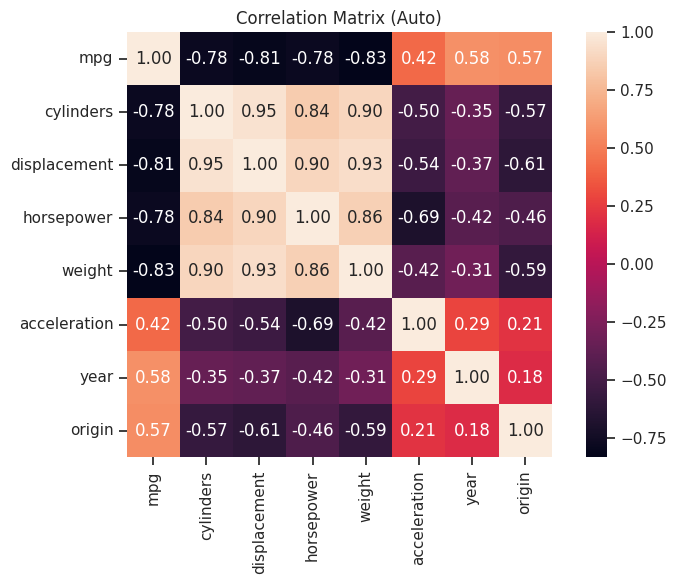

In [8]:
corr = df[numeric_cols].corr()
print("\nCorrelation matrix (numeric variables)\n", corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", square=True, cbar=True)
plt.title("Correlation Matrix (Auto)")
plt.tight_layout()
plt.show()


(c) Use the sm.OLS() function to perform a multiple linear regression
with mpg as the response and all other variables except name as
the predictors. Use the summarize() function to print the results.
Comment on the output. For instance:
* i. Is there a relationship between the predictors and the response? Use the anova_lm() function from statsmodels to
answer this question.
* ii. Which predictors appear to have a statistically significant
relationship to the response?
* iii. What does the coefficient for the year variable suggest?

In [16]:
formula = "mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + C(origin)"
model = smf.ols(formula=formula, data=df).fit()

print("\nOLS Summary\n")
print(model.summary())


anova_res = anova_lm(model, typ=2)
print("\n ANOVA \n")
print(round(anova_res, 5))


sig = model.pvalues[model.pvalues < 0.05].sort_values()
print("\n Significant predictors (p < 0.05):\n", round(sig,5))

beta_year = model.params.get('year', None)
if beta_year is not None:
    print(f"\n Estimated coefficient for year：{beta_year:.4f}")
    print("Interpretation: Holding other variables fixed, for every additional year, the expected mpg changes by approximately the units of the above coefficient.")


OLS Summary

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     224.5
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          1.79e-139
Time:                        14:32:14   Log-Likelihood:                -1020.5
No. Observations:                 392   AIC:                             2059.
Df Residuals:                     383   BIC:                             2095.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -17.9546     

(d) Produce some of diagnostic plots of the linear regression fit as
described in the lab. Comment on any problems you see with the
fit. Do the residual plots suggest any unusually large outliers?
Does the leverage plot identify any observations with unusually
high leverage?


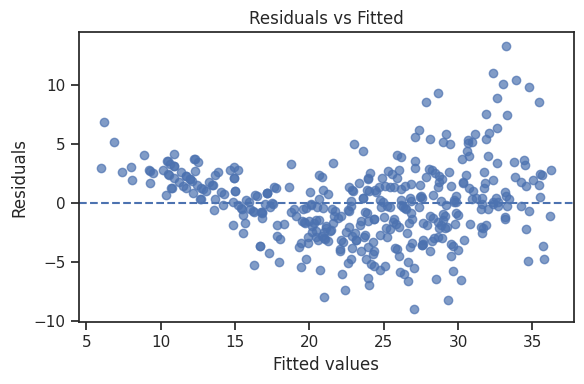

<Figure size 600x600 with 0 Axes>

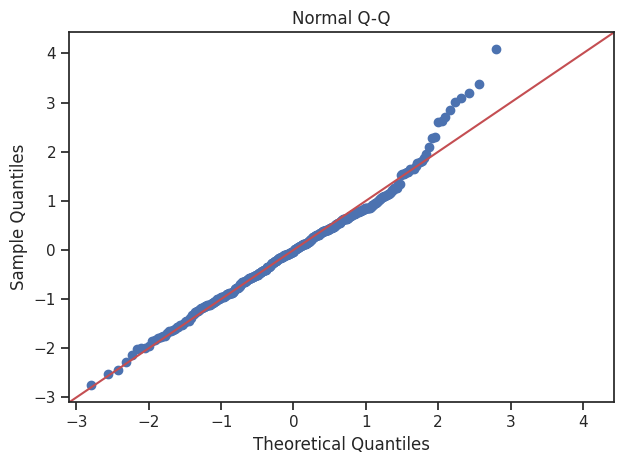

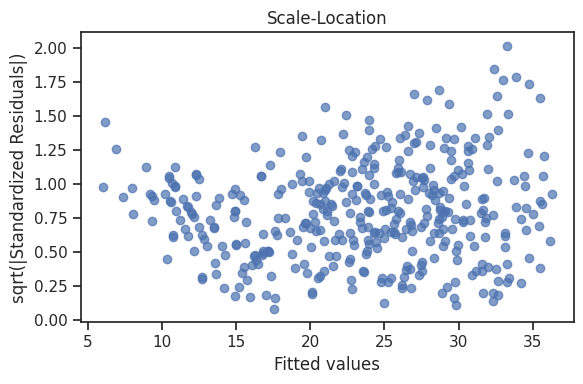

<Figure size 600x600 with 0 Axes>

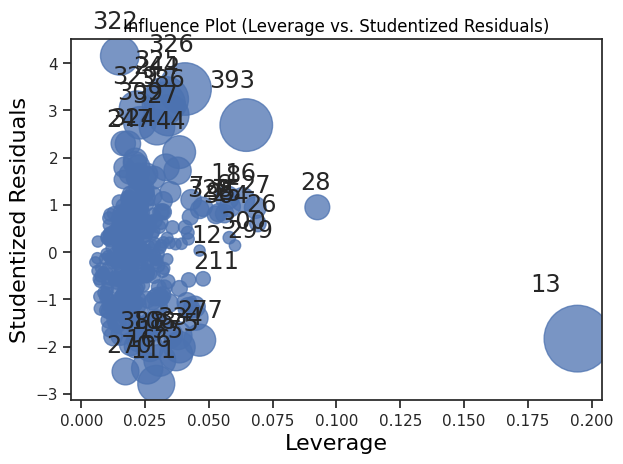

In [17]:
fitted = model.fittedvalues
resid = model.resid
resid_std = model.get_influence().resid_studentized_internal

plt.figure(figsize=(6, 4))
plt.scatter(fitted, resid, alpha=0.7)
plt.axhline(0, ls="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
qqplot(resid, line='45', fit=True)
plt.title("Normal Q-Q")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(fitted, np.sqrt(np.abs(resid_std)), alpha=0.7)
plt.xlabel("Fitted values")
plt.ylabel("sqrt(|Standardized Residuals|)")
plt.title("Scale-Location")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
influence_plot(model, criterion="cooks")
plt.title("Influence Plot (Leverage vs. Studentized Residuals)")
plt.tight_layout()
plt.show()


1. Residuals vs. Fitted

Observation:
The residuals show a clear fan-shaped trend, with increased residual volatility, particularly in areas with high predicted values ​​(higher MPG).

Interpretation:
This indicates the possibility of heterogeneous variation and suggests that the linear assumption may be insufficient, resulting in inconsistent variation across different regions.

Conclusion:
It is recommended to consider variable transformations (such as log(weight) or sqrt(displacement)) or add interactions to improve the model.

2. Normal Q-Q Plot

Observation:
Most points are aligned near the 45-degree red line, but the tail (upper right corner) deviates significantly.

Interpretation:
The residuals are generally normal, but there are a few heavy tails/outliers, indicating that extreme observations are affecting the residual distribution.

Conclusion:
Normality is generally observed, but attention should be paid to potential outliers.

3. Scale-Location Plot

Observations:
Around higher Fitted values, sqrt(|Standardized Residuals|) increases/decreases irregularly, but the fluctuations are uneven.

Interpretation:
This again supports the phenomenon of heterogeneity in the residuals → the variation changes with the predicted values.

Conclusion:
The model may require nonlinearity or variable transformation to stabilize the variation.

(e) Fit some models with interactions as described in the lab. Do
any interactions appear to be statistically significant?


In [24]:

formula_interactions = """
mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin
      + weight:horsepower + cylinders:displacement + year:origin
"""

model_int = smf.ols(formula=formula_interactions, data=df).fit()
print("\nSummary of OLS with Interactions\n")
print(model_int.summary())

anova_int = anova_lm(model_int, typ=2)
print("\nANOVA for interaction models\n")
print(round(anova_int,5))



Summary of OLS with Interactions

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.862
Method:                 Least Squares   F-statistic:                     244.8
Date:                Sun, 19 Oct 2025   Prob (F-statistic):          4.43e-159
Time:                        14:53:48   Log-Likelihood:                -968.25
No. Observations:                 392   AIC:                             1958.
Df Residuals:                     381   BIC:                             2002.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------

(f) Try a few different transformations of the variables, such as
log(X),√X, X2. Comment on your findings.


 Transformation model comparison (AIC / R^2 / Adj.R^2)
                                               AIC        R2    Adj_R2
model                                                                 
Contains interactions                  1958.491614  0.865316  0.861781
sqrt + quadratic term                  1958.754529  0.864536  0.861345
Origin When category + quadratic term  1959.285417  0.865043  0.861501
log conversion                         2000.345518  0.847829  0.845055
Original Linear                        2058.927826  0.824199  0.820527

 Model with the smallest AIC：
mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin
      + weight:horsepower + cylinders:displacement + year:origin



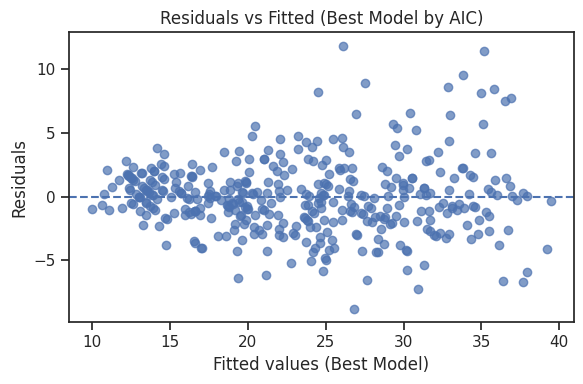

In [27]:
df_tr = df.copy()

# Positive variables suitable for log/sqrt
for col in ['displacement', 'horsepower', 'weight', 'acceleration']:
    df_tr[f'log_{col}'] = np.log(df_tr[col])
    df_tr[f'sqrt_{col}'] = np.sqrt(df_tr[col])
    df_tr[f'{col}_sq'] = df_tr[col] ** 2

# Example Model 1: Log Transform Partially Explained Variance
formula_log = """
mpg ~ cylinders + log_displacement + log_horsepower + log_weight + acceleration + year + origin
"""
model_log = smf.ols(formula=formula_log, data=df_tr).fit()

# Example Model 2: sqrt & Quadratic Term
formula_sqr = """
mpg ~ cylinders + sqrt_displacement + sqrt_horsepower + sqrt_weight + acceleration + year + origin
      + horsepower_sq + weight_sq
"""
model_sqr = smf.ols(formula=formula_sqr, data=df_tr).fit()

# Example Model 3: Treating origin as categorical + some quadratic terms
formula_cat = """
mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + C(origin)
      + horsepower_sq + weight_sq
"""
model_cat = smf.ols(formula=formula_cat, data=df_tr).fit()

print("\n Transformation model comparison (AIC / R^2 / Adj.R^2)")
def model_stats(m, name):
    return pd.Series({
        'model': name,
        'AIC': m.aic,
        'R2': m.rsquared,
        'Adj_R2': m.rsquared_adj
    })

comp = pd.concat([
    model_stats(model, "Original Linear"),
    model_stats(model_int, "Contains interactions"),
    model_stats(model_log, "log conversion"),
    model_stats(model_sqr, "sqrt + quadratic term"),
    model_stats(model_cat, "Origin When category + quadratic term")
], axis=1).T.set_index('model')
print(round(comp.sort_values('AIC'), 5))


best = min([model, model_int, model_log, model_sqr, model_cat], key=lambda m: m.aic)
print(f"\n Model with the smallest AIC：{best.model.formula if hasattr(best.model, 'formula') else '原始 OLS'}")

plt.figure(figsize=(6,4))
plt.scatter(best.fittedvalues, best.resid, alpha=0.7)
plt.axhline(0, ls="--")
plt.xlabel("Fitted values (Best Model)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Best Model by AIC)")
plt.tight_layout()
plt.show()
